Practical No 3:

Practical to implement simple GAN to generate synthetic images

What is a GAN?

A GAN (Generative Adversarial Network) consists of two neural networks trained together:

1️⃣ Generator (G)

Takes random noise as input

Tries to generate fake images

Goal: Fool the Discriminator


2️⃣ Discriminator (D)

Takes an image as input

Predicts real or fake

Goal: Correctly identify real vs generated images

They play a minimax game:

Generator tries to fool Discriminator

Discriminator tries to catch Generator


Over time:

Generator becomes better at creating realistic images

Discriminator becomes better at detecting fakes

GAN Architecture (Simple)


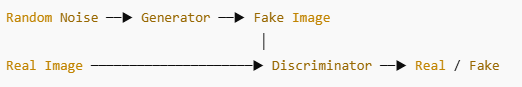


Dataset Used (MNIST)

Handwritten digits (0–9)

Image size: 28 × 28

Grayscale images

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [2]:
(X_train, _), (_, _) = mnist.load_data()

X_train = (X_train - 127.5) / 127.5   # Normalize to [-1, 1]
X_train = X_train.reshape(-1, 28*28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def build_generator():
    model = Sequential([
        Dense(256, input_dim=100),
        LeakyReLU(0.2),
        Dense(512),
        LeakyReLU(0.2),
        Dense(28*28, activation='tanh')
    ])
    return model

generator = build_generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
def build_discriminator():
    model = Sequential([
        Dense(512, input_dim=28*28),
        LeakyReLU(0.2),
        Dense(256),
        LeakyReLU(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(0.0002, 0.5),
        metrics=['accuracy']
    )
    return model

discriminator = build_discriminator()

In [5]:
discriminator.trainable = False

gan = Sequential([generator, discriminator])
gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5)
)

In [13]:
def train_gan(epochs=2000, batch_size=64):
    for epoch in range(epochs):
        # Train Discriminator
        real_imgs = X_train[np.random.randint(0, X_train.shape[0], batch_size)]
        noise = np.random.normal(0, 1, (batch_size, 100))
        fake_imgs = generator.predict(noise, verbose=0)

        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
        d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))

        # Train Generator
        noise = np.random.normal(0, 1, (batch_size, 100))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        if epoch % 500 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss_real[0]:.4f} | G Loss: {g_loss:.4f}")


In [14]:
def generate_images():
    noise = np.random.normal(0, 1, (10, 100))
    images = generator.predict(noise, verbose=0)
    images = images.reshape(10, 28, 28)

    plt.figure(figsize=(8,4))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
    plt.show()

Epoch 0 | D Loss: 4.4047 | G Loss: 0.0079
Epoch 500 | D Loss: 4.9329 | G Loss: 0.0043
Epoch 1000 | D Loss: 5.2580 | G Loss: 0.0030
Epoch 1500 | D Loss: 5.4965 | G Loss: 0.0023


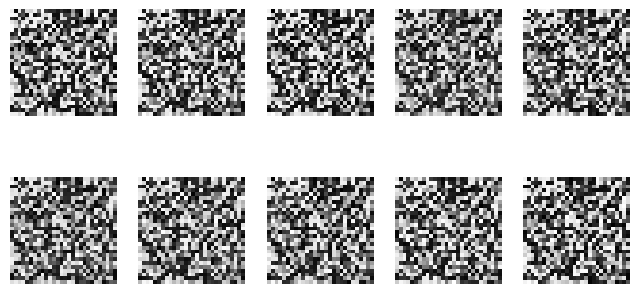

In [15]:
train_gan()
generate_images()